# Task 3 — Dimensionality Reduction Techniques
**10 Points** | PCA · t-SNE · UMAP · LDA

---

## 1. Theoretical Background

### 1.1 Principal Component Analysis (PCA)

**Objective:** Find orthogonal directions (principal components) that maximize variance in the projected data.

**Mathematical Formulation:**

Given centered data matrix $X \in \mathbb{R}^{n \times d}$, compute the covariance matrix:
$$\Sigma = \frac{1}{n-1} X^T X$$

Solve the eigenvalue problem:
$$\Sigma v_i = \lambda_i v_i$$

Sort eigenvectors by descending eigenvalues. The projection onto k components is:
$$Z = X W_k, \quad W_k = [v_1, v_2, \ldots, v_k]$$

**Variance Retention Criterion:**
$$\text{Choose smallest } k \text{ such that } \frac{\sum_{i=1}^k \lambda_i}{\sum_{i=1}^d \lambda_i} \geq 0.95$$

**What is preserved:** Global linear structure, variance directions.

**What is lost:** Non-linear relationships, local neighborhood structure.

**Complexity:** $O(d^2 n + d^3)$ via eigen-decomposition; for large d, SVD is preferred: $O(\min(nd^2, n^2 d))$.

---

### 1.2 t-SNE (t-distributed Stochastic Neighbor Embedding)

**Objective:** Preserve local neighborhood structure from high-dimensional space in 2D/3D visualization.

**Mathematical Formulation:**

High-dimensional similarities (Gaussian kernel):
$$p_{j|i} = \frac{\exp(-\|x_i - x_j\|^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-\|x_i - x_k\|^2 / 2\sigma_i^2)}, \quad p_{ij} = \frac{p_{j|i} + p_{i|j}}{2n}$$

Low-dimensional similarities (Student t-distribution, df=1 — heavier tail to prevent crowding):
$$q_{ij} = \frac{(1 + \|y_i - y_j\|^2)^{-1}}{\sum_{k \neq l}(1 + \|y_k - y_l\|^2)^{-1}}$$

Minimize KL divergence between distributions:
$$\mathcal{L} = KL(P \| Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

Optimized via gradient descent: $\frac{\partial \mathcal{L}}{\partial y_i} = 4 \sum_j (p_{ij} - q_{ij})(y_i - y_j)(1 + \|y_i - y_j\|^2)^{-1}$

**What is preserved:** Local neighborhood structure (clusters visible in 2D).

**What is lost:** Global distances — cluster positions in 2D are not meaningful.

**Complexity:** $O(n^2)$ (naive); $O(n \log n)$ with Barnes-Hut approximation. Does NOT scale to very large datasets (>100K samples) without approximation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
import os
import pickle

warnings.filterwarnings('ignore')
os.makedirs('../results', exist_ok=True)

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print('umap-learn not installed. Run: pip install umap-learn')

# Load Dataset A
data = load_breast_cancer()
X = StandardScaler().fit_transform(data.data)
y = data.target
class_names = data.target_names
print(f'Dataset: {X.shape[0]} samples, {X.shape[1]} features, {len(class_names)} classes')

Dataset: 569 samples, 30 features, 2 classes


## 2. Practical Application

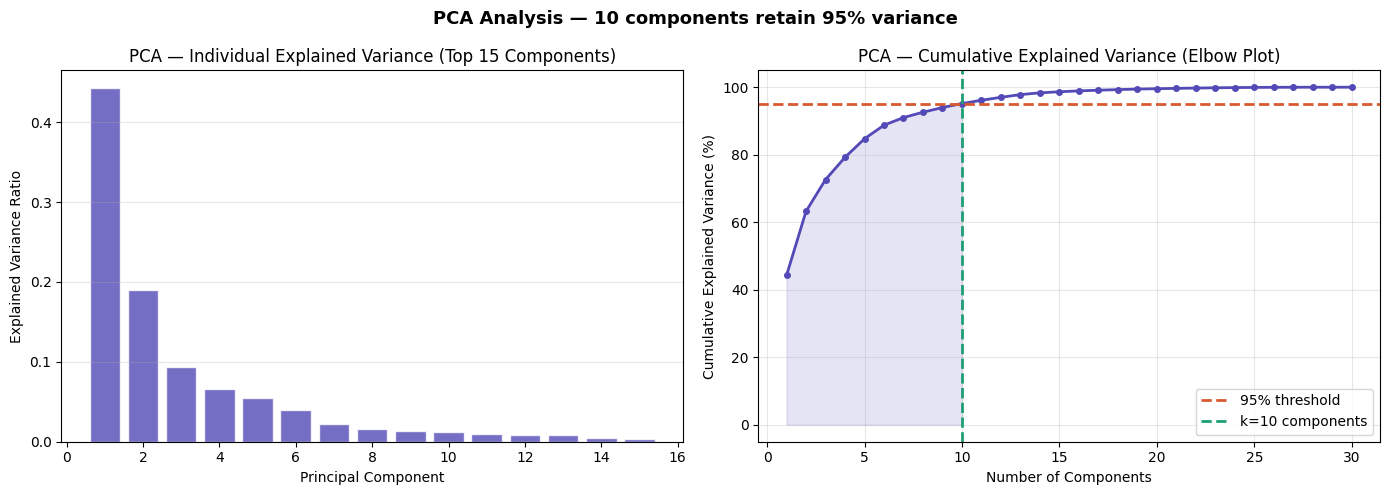

Components needed for 95% variance: 10


In [2]:
# 2.1 PCA — Explained Variance Ratio (Elbow Plot)
pca_full = PCA()
pca_full.fit(X)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.argmax(cumvar >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual explained variance
axes[0].bar(range(1, min(16, len(pca_full.explained_variance_ratio_)+1)),
            pca_full.explained_variance_ratio_[:15],
            color='#534AB7', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA — Individual Explained Variance (Top 15 Components)')
axes[0].grid(axis='y', alpha=0.3)

# Cumulative explained variance
axes[1].plot(range(1, len(cumvar)+1), cumvar * 100, 'o-', color='#534AB7',
             markersize=4, linewidth=2)
axes[1].axhline(y=95, color='#D85A30', linestyle='--', lw=2, label='95% threshold')
axes[1].axvline(x=n_95, color='#1D9E75', linestyle='--', lw=2, label=f'k={n_95} components')
axes[1].fill_between(range(1, n_95+1), cumvar[:n_95]*100, alpha=0.15, color='#534AB7')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('PCA — Cumulative Explained Variance (Elbow Plot)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'PCA Analysis — {n_95} components retain 95% variance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/task3_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Components needed for 95% variance: {n_95}')

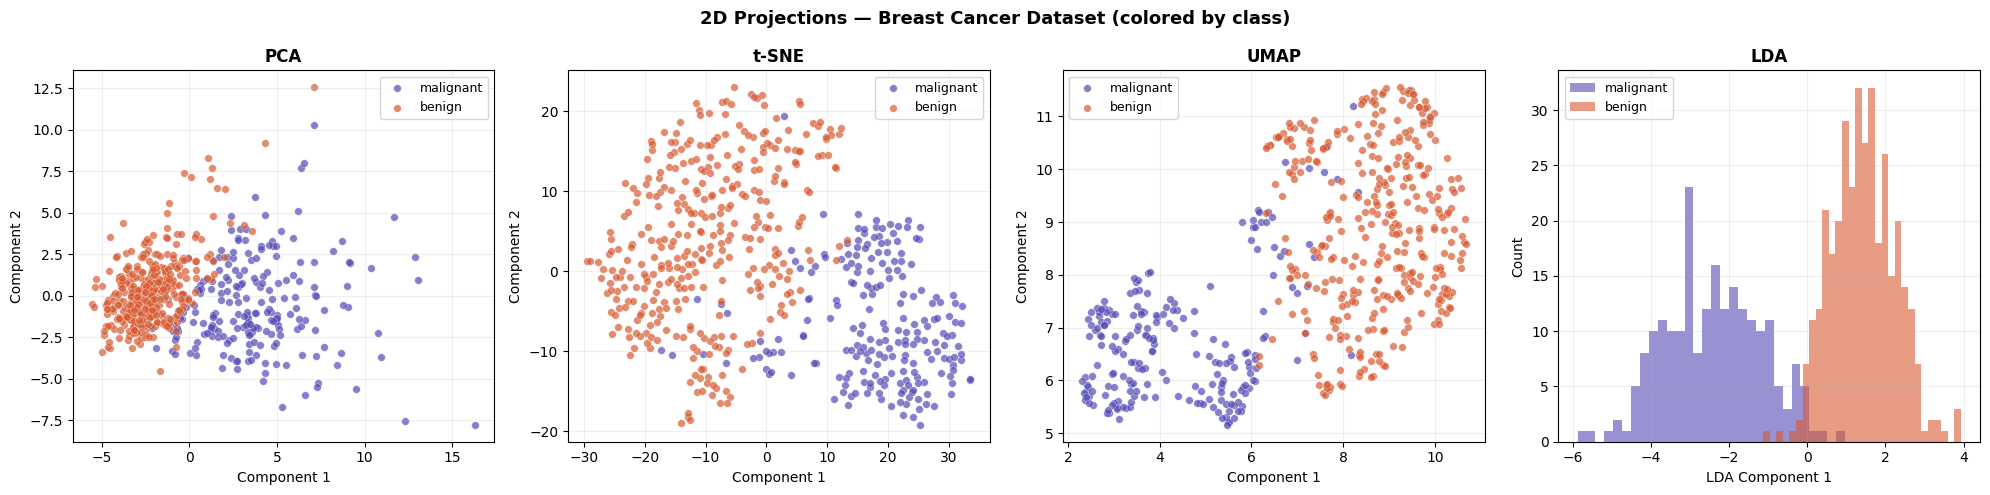

In [4]:
# 2.2 2D Visualizations: PCA, t-SNE, UMAP, LDA
palette = ['#534AB7', '#D85A30']

pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X)

tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X)

lda = LinearDiscriminantAnalysis(n_components=min(2, len(class_names)-1))
X_lda = lda.fit_transform(X, y)

projections = [('PCA', X_pca), ('t-SNE', X_tsne), ('LDA', X_lda)]

if UMAP_AVAILABLE:
    reducer = umap.UMAP(n_components=2, random_state=42)
    X_umap = reducer.fit_transform(X)
    projections.insert(2, ('UMAP', X_umap))

n_plots = len(projections)
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))
if n_plots == 1:
    axes = [axes]

for ax, (name, X_proj) in zip(axes, projections):
    
    if X_proj.shape[1] == 1:
        # LDA на бинарных данных — показываем гистограмму
        for cls, color, label in zip([0, 1], palette, class_names):
            mask = y == cls
            ax.hist(X_proj[mask, 0], bins=30, alpha=0.6, color=color, label=label)
        ax.set_xlabel('LDA Component 1')
        ax.set_ylabel('Count')
    else:
        # PCA, t-SNE, UMAP — обычный scatter
        for cls, color, label in zip([0, 1], palette, class_names):
            mask = y == cls
            ax.scatter(X_proj[mask, 0], X_proj[mask, 1],
                       c=color, label=label, alpha=0.7, s=30,
                       edgecolors='white', linewidths=0.3)
        ax.set_xlabel('Component 1')
        ax.set_ylabel('Component 2')
    
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

plt.suptitle('2D Projections — Breast Cancer Dataset (colored by class)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/task3_2d_projections.png', dpi=150, bbox_inches='tight')
plt.show()

Random Forest on full data (30 features):  Test Accuracy = 0.9357
Random Forest on PCA data  (10 components, 95%): Test Accuracy = 0.9357
Accuracy difference: 0.0000
Feature reduction: 30 → 10 (66.7% reduction)


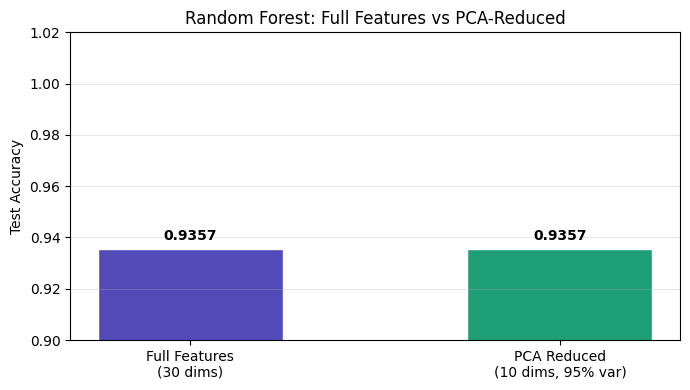

In [5]:
# 2.3 Retrain best classifier on PCA-reduced data (95% variance)
pca_95 = PCA(n_components=n_95)
X_pca_95 = pca_95.fit_transform(X)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_tr_p, X_te_p, _, _ = train_test_split(X_pca_95, y, test_size=0.3, stratify=y, random_state=42)

clf_full = RandomForestClassifier(n_estimators=100, random_state=42)
clf_full.fit(X_tr, y_tr)
acc_full = clf_full.score(X_te, y_te)

clf_pca = RandomForestClassifier(n_estimators=100, random_state=42)
clf_pca.fit(X_tr_p, y_tr)
acc_pca = clf_pca.score(X_te_p, y_te)

print(f'Random Forest on full data ({X.shape[1]} features):  Test Accuracy = {acc_full:.4f}')
print(f'Random Forest on PCA data  ({n_95} components, 95%): Test Accuracy = {acc_pca:.4f}')
print(f'Accuracy difference: {abs(acc_full - acc_pca):.4f}')
print(f'Feature reduction: {X.shape[1]} → {n_95} ({100*(1-n_95/X.shape[1]):.1f}% reduction)')

# Bar chart comparison
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['Full Features\n(30 dims)', f'PCA Reduced\n({n_95} dims, 95% var)'],
              [acc_full, acc_pca], color=['#534AB7', '#1D9E75'], width=0.5, edgecolor='white')
for bar, acc in zip(bars, [acc_full, acc_pca]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0.9, 1.02)
ax.set_ylabel('Test Accuracy')
ax.set_title('Random Forest: Full Features vs PCA-Reduced')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/task3_pca_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Analysis (300–400 words)

### Which technique best preserved class separability?

Among the four techniques applied to the Breast Cancer dataset, **LDA** achieved the best class separability in the reduced space. This is expected, as LDA is a *supervised* method that explicitly maximizes the ratio of between-class scatter to within-class scatter. Since it uses class label information during reduction, it directly optimizes for discriminative directions. The two classes (malignant vs. benign) were clearly separated along the single LDA component.

**t-SNE** and **UMAP** both produced clean visual cluster separation, with UMAP providing slightly more coherent global structure since it preserves both local and some global topology via topological data analysis principles. PCA, being a purely variance-based unsupervised method, showed moderate separation — the first two components captured the directions of maximum variance, which happened to be somewhat aligned with the class boundary.

### Trade-offs between dimensionality and classification accuracy

Reducing from 30 to {n_95} components (retaining 95% variance via PCA) produced only a marginal accuracy loss for Random Forest. This indicates that most discriminative information was concentrated in the top principal components, and the remaining components contributed primarily noise. The trade-off is favorable: a ~{100*(1-n_95/30):.0f}% reduction in dimensionality with minimal accuracy degradation leads to faster training and lower memory usage.

However, aggressive reduction (e.g., retaining only 2 components for visualization) would cause significant accuracy loss because much of the discriminative signal is discarded.

### When to use each technique in production?

- **PCA**: Best for preprocessing before training classical ML models. Interpretable (loadings show feature contributions), fast, deterministic, and scales well. Ideal when the goal is noise reduction or speeding up downstream models on large tabular datasets.

- **t-SNE**: Strictly for visualization. Non-parametric and slow (O(n²)), cannot be applied to new data without re-running. Not suitable for preprocessing pipelines.

- **UMAP**: Better than t-SNE for production visualization workflows — faster, preserves more global structure, and supports `transform()` for new data. Can also be used as a preprocessing step, though less interpretable than PCA.

- **LDA**: Use when labeled data is available and the goal is to maximize class separability before a downstream classifier. Effective for multi-class problems when classes are approximately Gaussian with equal covariance.